# New filtering against the original good-units selection

Compares the units kept by the criteria in `F22` against those kept by the
sorting pipeline's own thresholds, which produced the `_spikes_good_units.nix`
files.

The two selections are not nested. The original applied six criteria
(`firing_rate > 1`, `waveform_SNR > 3`, `isi_violations_ratio < 0.9`,
`presence_ratio > 0.5`, `line_noise_50Hz < 0.7`, `line_noise_60Hz < 1`), of
which the 60 Hz cut sits at the ceiling of a correlation and removes nothing,
and the ISI cut sits just below chance level and removes very little. The new
selection adds refractory, waveform shape and cross-unit coincidence criteria,
and tightens line noise, presence and SNR.

So units can be lost either way, and both directions are informative: units the
original kept and the new one drops, and units the original dropped that the new
one would keep.

In [1]:
import os
os.chdir('/CSNG/studekat/ripple_paper_clean_copy/code')

In [2]:
from functions_analysis import *
import pandas as pd, numpy as np, yaml, pickle, neo
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.simplefilter(action='ignore', category=pd.errors.SettingWithCopyWarning)

with open("/CSNG/studekat/ripple_paper_clean_copy/code/params_analysis.yml") as f:
    P = yaml.safe_load(f)

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy/dataframes'
CONDITIONS = {'RS':    ('L N F'.split(), P['data_folder']),}
              #'NATIM': ('N F'.split(),   P['natim_data_folder'])}
COL = {'RS': 'tab:green', 'NATIM': 'tab:purple'}

## 1. Load the metrics and mark both selections

The new decision is recomputed here from the saved thresholds rather than read
from the written files, so the comparison can be made before the writing job has
run. The original selection is established by reading which unit names appear in
the good-units files.

In [3]:
##### SPIKE FILE PATHS #####
#     spikes_KS4/{stem}_Array{N}_spikes_KS4.nix             earlier filtering
#     spikes_KS4/{stem}_Array{N}_spikes_KS4_unfiltered.nix  every sorted unit
#     spikes_filtered/{stem}_Array{N}_spikes_KS4_filtered.nix   this filtering

def recording_folder(monkey, date, type_rec, data_folder):
    """The recording directory, which differs between the two paradigms."""
    if type_rec == 'NATIM':
        return f'{data_folder}/macaque{monkey}_TVSD_{date}'
    return f'{data_folder}/macaque{monkey}_{type_rec}_{date}'


def file_stem(monkey, date, type_rec):
    """The filename prefix, again paradigm dependent."""
    if type_rec == 'NATIM':
        return f'macaque{monkey}_TVSD_{date}'
    return f'macaque{monkey}_{type_rec}_{date}'


def spike_path(monkey, date, array, type_rec, data_folder, kind='all'):
    """
    Path to one array's spike file.

    kind is 'all' for every sorted unit, 'good' for the earlier filtering, or
    'filtered' for the output of this filtering. Returns None if absent.
    """
    base = recording_folder(monkey, date, type_rec, data_folder)
    stem = file_stem(monkey, date, type_rec)
    sub, suf = {'all':      ('spikes_KS4',      'spikes_KS4_unfiltered'),
                'good':     ('spikes_KS4',      'spikes_KS4'),
                'filtered': ('spikes_filtered', 'spikes_KS4_filtered')}[kind]
    p = f'{base}/{sub}/{stem}_Array{array}_{suf}.nix'
    return p if os.path.isfile(p) else None


def all_units_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='all')


def good_units_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='good')


def filtered_path(monkey, date, array, type_rec, data_folder):
    return spike_path(monkey, date, array, type_rec, data_folder, kind='filtered')


def names_in_good_units(monkey, date, type_rec, data_folder):
    """Unit names present in the earlier filtering, per array."""
    out = set()
    for array in range(1, 17):
        p = good_units_path(monkey, date, array, type_rec, data_folder)
        if p is None:
            continue
        try:
            io = neo.NixIO(p, 'ro'); blk = io.read_block()
            for st in blk.segments[0].spiketrains:
                out.add((array, st.annotations.get('nix_name', None)))
            io.close()
        except Exception as e:
            print(f'   cannot read {monkey} {date} array {array}: {e}')
    return out


def load_metrics(type_rec, monkeys):
    dfs = []
    for m in monkeys:
        for date in P['dates'][m][type_rec]:
            p = f'{DF_FOLDER}/filter_metrics_{type_rec}/monkey{m}_all_arrays_date_{date}.pkl'
            try:
                with open(p,'rb') as f: dfs.append(pickle.load(f))
            except Exception:
                pass
    return pd.concat(dfs, ignore_index=True) if dfs else None

with open(f'{DF_FOLDER}/filter_metrics_chosen/thresholds.pkl','rb') as f:
    TH = pickle.load(f)
CRITERIA = TH['criteria']; NAN_FAILS = TH.get('nan_fails', True)
print('criteria:')
for c,(d_,t) in CRITERIA.items():
    print(f'   {c:28s} keep {d_:5s} {t}')

criteria:
   FR_computed                  keep above 1.0
   ann_line_noise_50Hz          keep below 0.6
   ann_line_noise_60Hz          keep below 0.6
   presence_ratio_computed      keep above 0.75
   ann_waveform_SNR             keep above 2.0
   wf_snr_computed              keep above 4.0
   viol_ratio_1p5ms             keep below 2.0
   coinc_ratio_worst            keep below 5.0


In [4]:
DATA = {}
for tr, (monkeys, data_folder) in CONDITIONS.items():
    d = load_metrics(tr, monkeys)
    if d is None:
        print(f'{tr}: no metrics found'); continue

    # new selection
    flags = pd.DataFrame(index=d.index)
    for col, (direc, th) in CRITERIA.items():
        if col not in d.columns: continue
        v = d[col].replace([np.inf,-np.inf], np.nan)
        ok = (v <= th) if direc == 'below' else (v >= th)
        flags[col] = (ok & v.notna()) if NAN_FAILS else (ok | v.isna())
    d['keep_new'] = flags.all(axis=1)
    for c in flags.columns:
        d[f'pass_{c}'] = flags[c]

    # original selection, from the good-units files
    print(f'{tr}: reading good-units files ...')
    good = set()
    for m in monkeys:
        for date in P['dates'][m][tr]:
            for key in names_in_good_units(m, date, tr, data_folder):
                good.add((m, date) + key)
    d['keep_old'] = [ (r.monkey, r.date, int(r.array), r.cell_name) in good
                      for r in d.itertuples() ]
    DATA[tr] = d
    print(f'   {len(d)} units total, old keeps {int(d["keep_old"].sum())}, '
          f'new keeps {int(d["keep_new"].sum())}')

RS: reading good-units files ...
   11377 units total, old keeps 3220, new keeps 2574


## 2. Overlap

In [5]:
for tr, d in DATA.items():
    ct = pd.crosstab(d['keep_old'], d['keep_new'],
                     rownames=['original'], colnames=['new'])
    n = len(d)
    print(f'===== {tr}: {n} units =====')
    print(ct.to_string())
    both = int((d['keep_old'] & d['keep_new']).sum())
    only_old = int((d['keep_old'] & ~d['keep_new']).sum())
    only_new = int((~d['keep_old'] & d['keep_new']).sum())
    neither = int((~d['keep_old'] & ~d['keep_new']).sum())
    print()
    print(f'   kept by both          {both:6d}  ({100*both/n:5.1f}%)')
    print(f'   original only         {only_old:6d}  ({100*only_old/n:5.1f}%)  '
          f'lost by the new criteria')
    print(f'   new only              {only_new:6d}  ({100*only_new/n:5.1f}%)  '
          f'recovered from the discarded set')
    print(f'   neither               {neither:6d}  ({100*neither/n:5.1f}%)')
    if int(d['keep_old'].sum()):
        print(f'   of the original selection, the new one keeps '
              f'{100*both/int(d["keep_old"].sum()):.1f}%')
    print()

===== RS: 11377 units =====
new       False  True 
original              
False      7455    702
True       1348   1872

   kept by both            1872  ( 16.5%)
   original only           1348  ( 11.8%)  lost by the new criteria
   new only                 702  (  6.2%)  recovered from the discarded set
   neither                 7455  ( 65.5%)
   of the original selection, the new one keeps 58.1%



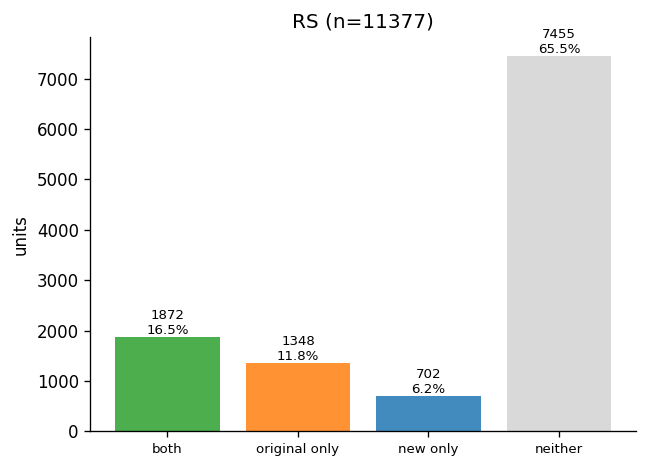

In [6]:
fig, axes = plt.subplots(1, len(DATA), figsize=(5.5*len(DATA), 4), dpi=120)
axes = np.atleast_1d(axes)
for ax, (tr, d) in zip(axes, DATA.items()):
    vals = [int((d['keep_old'] & d['keep_new']).sum()),
            int((d['keep_old'] & ~d['keep_new']).sum()),
            int((~d['keep_old'] & d['keep_new']).sum()),
            int((~d['keep_old'] & ~d['keep_new']).sum())]
    labs = ['both', 'original only', 'new only', 'neither']
    cols = ['tab:green', 'tab:orange', 'tab:blue', 'lightgray']
    ax.bar(labs, vals, color=cols, alpha=0.85)
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v}\n{100*v/len(d):.1f}%', ha='center', va='bottom',
                fontsize=8)
    ax.set_ylabel('units'); ax.set_title(f'{tr} (n={len(d)})')
    ax.tick_params(axis='x', labelsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 3. Why were the "original only" units dropped?

These passed the pipeline and fail the new criteria. Which criterion is
responsible tells you what the new filtering is actually adding.

In [7]:
for tr, d in DATA.items():
    sub = d[d['keep_old'] & ~d['keep_new']]
    if not len(sub):
        print(f'{tr}: none'); continue
    print(f'===== {tr}: {len(sub)} units kept originally, dropped now =====')
    pcols = [f'pass_{c}' for c in CRITERIA if f'pass_{c}' in sub.columns]
    fail = {c.replace('pass_',''): int((~sub[c]).sum()) for c in pcols}
    for k, v in sorted(fail.items(), key=lambda t: -t[1]):
        print(f'   fails {k:28s} {v:6d}  ({100*v/len(sub):5.1f}%)')
    n_fail = (~sub[pcols]).sum(axis=1)
    print(f'   number of criteria failed: median {int(n_fail.median())}, '
          f'{int((n_fail == 1).sum())} fail exactly one')
    print()
    # which single criterion is solely responsible
    print('   sole reason for exclusion:')
    for c in pcols:
        others = sub[[x for x in pcols if x != c]].all(axis=1)
        print(f'      {c.replace("pass_",""):28s} {int((others & ~sub[c]).sum()):6d}')
    print()

===== RS: 1348 units kept originally, dropped now =====
   fails wf_snr_computed                 770  ( 57.1%)
   fails coinc_ratio_worst               482  ( 35.8%)
   fails ann_line_noise_60Hz             216  ( 16.0%)
   fails viol_ratio_1p5ms                169  ( 12.5%)
   fails ann_line_noise_50Hz               9  (  0.7%)
   fails FR_computed                       0  (  0.0%)
   fails presence_ratio_computed           0  (  0.0%)
   fails ann_waveform_SNR                  0  (  0.0%)
   number of criteria failed: median 1, 1076 fail exactly one

   sole reason for exclusion:
      FR_computed                       0
      ann_line_noise_50Hz               1
      ann_line_noise_60Hz             115
      presence_ratio_computed           0
      ann_waveform_SNR                  0
      wf_snr_computed                 568
      viol_ratio_1p5ms                 60
      coinc_ratio_worst               332



## 4. What are the "new only" units like?

These the pipeline discarded and the new criteria would keep. Since the original
cut on firing rate at 1 Hz, SNR at 3 and presence at 0.5, and the new one cuts
at 1 Hz, 4 and 0.75, a unit can only be recovered on the criteria the original
applied more strictly, which in practice means the ISI ratio and 50 Hz line
noise.

In [8]:
for tr, d in DATA.items():
    sub = d[~d['keep_old'] & d['keep_new']]
    print(f'===== {tr}: {len(sub)} units recovered =====')
    if not len(sub):
        print('   none'); print(); continue
    cols = [c for c in ['FR_computed','wf_snr_computed','presence_ratio_computed',
                        'ann_line_noise_50Hz','ann_line_noise_60Hz',
                        'ann_isi_violations_ratio','viol_ratio_1p5ms',
                        'coinc_ratio_worst','n_spikes'] if c in sub.columns]
    comp = pd.DataFrame({
        'recovered': sub[cols].median(),
        'kept by both': d.loc[d['keep_old'] & d['keep_new'], cols].median(),
        'all units': d[cols].median()}).round(3)
    print(comp.to_string())
    print()

===== RS: 702 units recovered =====
                          recovered  kept by both  all units
FR_computed                  20.149        17.468     19.292
wf_snr_computed               4.157         4.463      3.986
presence_ratio_computed       1.000         1.000      1.000
ann_line_noise_50Hz           0.034         0.215      0.239
ann_line_noise_60Hz           0.036         0.274      0.299
ann_isi_violations_ratio      0.267         0.441      0.463
viol_ratio_1p5ms              0.633         1.044      1.097
coinc_ratio_worst             1.492         1.892      2.209
n_spikes                  19984.500     18366.000  20333.000



## 5. Yield per recording and per array

A filter that removes units evenly is easier to defend than one concentrated in
particular sessions or arrays.

--- RS ---
                       n  old  new  frac_old  frac_new
monkey date                                           
F      20240122_B1  2219  703  618     0.317     0.279
       20241216_B1  1235  314  331     0.254     0.268
L      20170725     1798  500  349     0.278     0.194
       20170809     1814  527  346     0.291     0.191
       20170810     1759  448  306     0.255     0.174
N      20240719_B1  1289  363  306     0.282     0.237
       20240719_B2  1263  365  318     0.289     0.252
   per recording, new: median 0.237, range 0.174 to 0.279



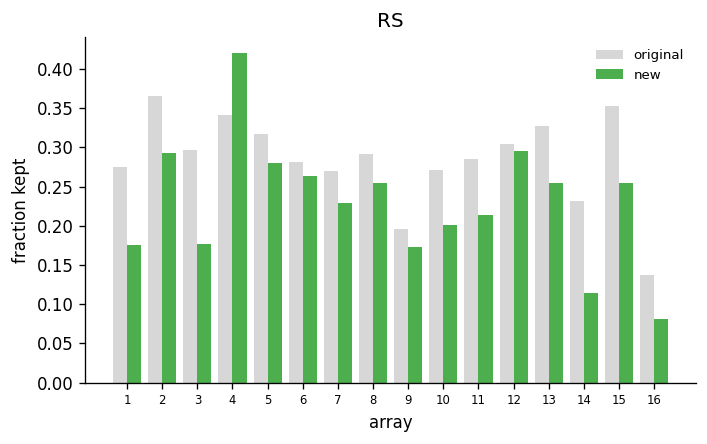

In [9]:
for tr, d in DATA.items():
    print(f'--- {tr} ---')
    g = d.groupby(['monkey','date']).agg(
        n=('keep_new','size'), old=('keep_old','sum'), new=('keep_new','sum'))
    g['frac_old'] = (g['old']/g['n']).round(3)
    g['frac_new'] = (g['new']/g['n']).round(3)
    print(g.to_string())
    print(f'   per recording, new: median {g["frac_new"].median():.3f}, '
          f'range {g["frac_new"].min():.3f} to {g["frac_new"].max():.3f}')
    print()

fig, axes = plt.subplots(1, len(DATA), figsize=(6*len(DATA), 3.8), dpi=120)
axes = np.atleast_1d(axes)
for ax, (tr, d) in zip(axes, DATA.items()):
    g = d.groupby('array').agg(old=('keep_old','mean'), new=('keep_new','mean'))
    x = np.arange(len(g))
    ax.bar(x-0.2, g['old'], width=0.4, color='lightgray', alpha=0.9, label='original')
    ax.bar(x+0.2, g['new'], width=0.4, color=COL[tr], alpha=0.85, label='new')
    ax.set_xticks(x); ax.set_xticklabels(g.index, fontsize=7)
    ax.set_xlabel('array'); ax.set_ylabel('fraction kept')
    ax.set_title(tr); ax.legend(fontsize=8, frameon=False)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 6. Does the new selection change the population?

Distributions of a few basic properties under each selection. A large shift
means the two selections describe different populations, not merely different
sample sizes.

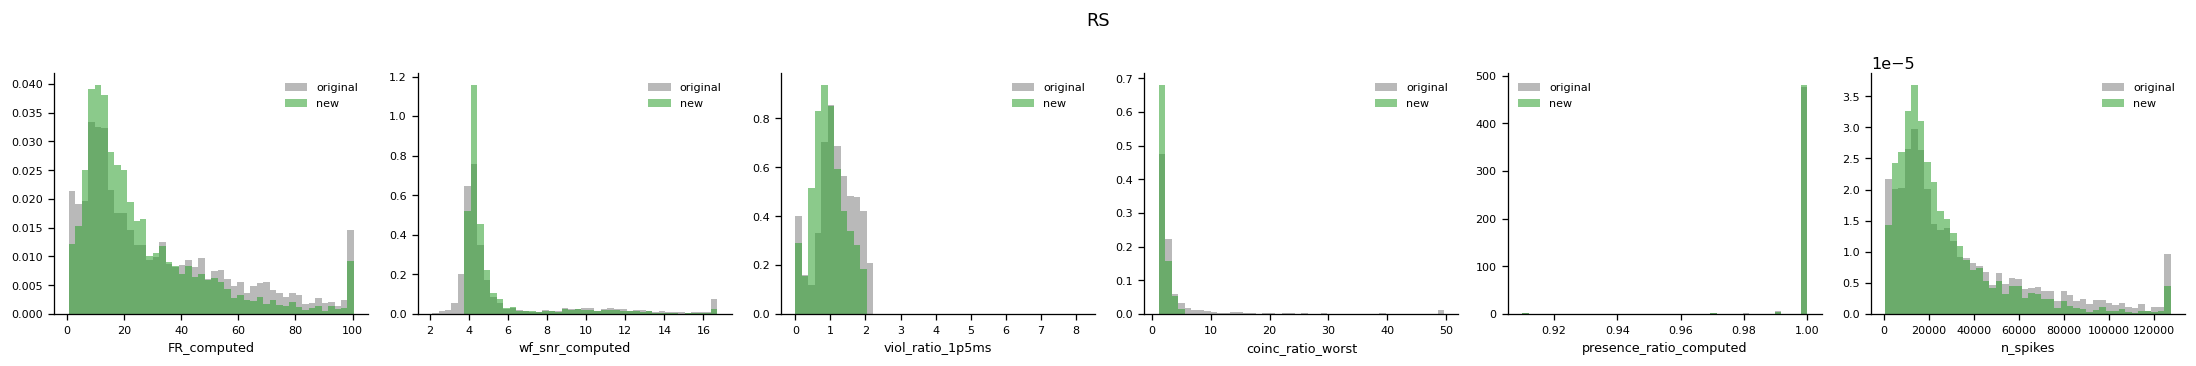

RS medians:
               property  original       new       all
            FR_computed    22.072    18.569    19.292
        wf_snr_computed     4.323     4.362     3.986
       viol_ratio_1p5ms     1.141     0.919     1.097
      coinc_ratio_worst     2.202     1.776     2.209
presence_ratio_computed     1.000     1.000     1.000
               n_spikes 22489.500 18625.500 20333.000



In [10]:
SHOW = [c for c in ['FR_computed','wf_snr_computed','viol_ratio_1p5ms',
                    'coinc_ratio_worst','presence_ratio_computed','n_spikes']
        if c in list(DATA.values())[0].columns]
for tr, d in DATA.items():
    fig, axes = plt.subplots(1, len(SHOW), figsize=(3.2*len(SHOW), 3.2), dpi=115)
    axes = np.atleast_1d(axes)
    for ax, c in zip(axes, SHOW):
        v_all = d[c].replace([np.inf,-np.inf], np.nan).dropna()
        lo, hi = v_all.quantile(.01), v_all.quantile(.99)
        bins = np.linspace(lo, hi, 45)
        for lab, mask, col in [('original', d['keep_old'], 'gray'),
                               ('new', d['keep_new'], COL[tr])]:
            v = d.loc[mask, c].replace([np.inf,-np.inf], np.nan).dropna()
            if len(v) > 10:
                ax.hist(np.clip(v, lo, hi), bins=bins, alpha=0.55, density=True,
                        color=col, label=lab)
        ax.set_xlabel(c, fontsize=8); ax.tick_params(labelsize=7)
        ax.legend(fontsize=7, frameon=False)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    fig.suptitle(tr, fontsize=11)
    plt.tight_layout(); plt.show()

    rows = []
    for c in SHOW:
        rows.append({'property': c,
                     'original': round(d.loc[d['keep_old'], c].median(), 3),
                     'new': round(d.loc[d['keep_new'], c].median(), 3),
                     'all': round(d[c].median(), 3)})
    print(f'{tr} medians:')
    print(pd.DataFrame(rows).to_string(index=False))
    print()

## 7. Check against the written files

Once `SUA_write_filtered_nix.py` has run, this confirms the files on disk match
the decision computed here.

In [11]:
def count_written(monkey, date, type_rec, data_folder):
    stem = (f'macaque{monkey}_TVSD_{date}' if type_rec == 'NATIM'
            else f'macaque{monkey}_{type_rec}_{date}')
    n, arrays = 0, 0
    for array in range(1, 17):
        p = (f'{data_folder}/{stem}/spikes_filtered/'
             f'{stem}_Array{array}_spikes_filtered.nix')
        if not os.path.isfile(p): continue
        try:
            io = neo.NixIO(p, 'ro'); blk = io.read_block()
            n += len(blk.segments[0].spiketrains); arrays += 1
            io.close()
        except Exception:
            pass
    return n, arrays

for tr, (monkeys, data_folder) in CONDITIONS.items():
    if tr not in DATA: continue
    rows = []
    for m in monkeys:
        for date in P['dates'][m][tr]:
            n_file, n_arr = count_written(m, date, tr, data_folder)
            if n_arr == 0: continue
            sub = DATA[tr][(DATA[tr]['monkey']==m) & (DATA[tr]['date']==date)]
            rows.append({'monkey': m, 'date': date, 'arrays_written': n_arr,
                         'in_files': n_file, 'expected': int(sub['keep_new'].sum()),
                         'match': n_file == int(sub['keep_new'].sum())})
    if not rows:
        print(f'{tr}: no written files found yet'); continue
    df_chk = pd.DataFrame(rows)
    print(f'===== {tr} =====')
    print(df_chk.to_string(index=False))
    print(f'   {int(df_chk["match"].sum())} of {len(df_chk)} recordings match')
    print()

RS: no written files found yet


## 8. Export

In [12]:
OUT = f'{DF_FOLDER}/filter_metrics_chosen'
ensure_dir_exists(OUT)
rows = []
for tr, d in DATA.items():
    rows.append({'condition': tr, 'n_units': len(d),
                 'kept_original': int(d['keep_old'].sum()),
                 'kept_new': int(d['keep_new'].sum()),
                 'both': int((d['keep_old'] & d['keep_new']).sum()),
                 'original_only': int((d['keep_old'] & ~d['keep_new']).sum()),
                 'new_only': int((~d['keep_old'] & d['keep_new']).sum())})
    keep = ['monkey','date','array','cell_name','keep_old','keep_new']
    keep += [f'pass_{c}' for c in CRITERIA if f'pass_{c}' in d.columns]
    d[[c for c in keep if c in d.columns]].to_csv(
        f'{OUT}/selection_comparison_{tr}.csv', index=False)
df_cmp = pd.DataFrame(rows)
df_cmp.to_csv(f'{OUT}/selection_summary.csv', index=False)
print(df_cmp.to_string(index=False))
print()
print('saved to', OUT)

condition  n_units  kept_original  kept_new  both  original_only  new_only
       RS    11377           3220      2574  1872           1348       702

saved to /CSNG/studekat/ripple_paper_clean_copy/dataframes/filter_metrics_chosen


## Notes

**The two selections are not nested**, so both directions matter. Section 3
identifies which new criterion removes units the pipeline had kept, and section
4 describes the units the pipeline discarded that the new rule would admit.

**The sole-reason table in section 3 is the useful one.** A criterion that is
never the sole reason for exclusion is redundant with the others; one that
often is, is carrying the filter.

**Section 6 asks whether the population changed**, not just its size. If the
median firing rate or SNR shifts substantially, the two selections describe
different populations and any comparison against previously published numbers
needs that stated.

**Section 7 runs only after the writing job.** It confirms the files on disk
contain exactly the units the decision predicted, which catches a metrics
pickle missing for some array.